# Higer-Order Differential Equations and Systems of 1st-Order Differential Equations


In [7]:
# importing libraries
import numpy as np
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

# Definition of the IVP

In [8]:
# Define the IVP:

# Diff. Eqn.: y'' = f(x,y,y') = f(x,y0,y1)
# Define the IVP for Part (b)
def f(t, y):
    rhs = np.zeros((2, 1))
    # y[0] is y, y[1] is y'
    rhs[0] = y[1]
    rhs[1] = (2/t)*y[1] - (2/t**2)*y[0] + t * np.log(t)
    return rhs


# Initial Condition
y0 = np.array([[-0.4],[-0.6]])

In [9]:
# Explicit Runge-Kutta 4th-order Method
def erk4(t, w, h):
    s1 = f(t, w)
    s2 = f(t + 0.5*h, w + 0.5*h*s1)
    s3 = f(t + 0.5*h, w + 0.5*h*s2)
    s4 = f(t + h, w + h*s3)

    phi = (1/6)*(s1 + 2*s2 + 2*s3 + s4)
    return phi

In [10]:
# Time-stepping method to solve Initial Value Problems (IVPs)
# Use with f(t,y) to evaluate rhs of differential equation
# Input: interval endoints a and b,
#        initial condition y0,
#        number of steps n,
#        time-stepping flag s,
#                           s = 1:  Euler
#                           s = 2:  Explicit Trapezoid Method
#                           s = 4:  Runge-Kutta 4th-order
#
# Output: time steps t, approximate solution w
# Usage: euler(a,b,y_0,n)
# Example: euler(0,1,1,10)
def tstep(a, b, y0, n, mthd):
    m = np.size(y0)
    t = np.zeros(n+1)
    w = np.zeros((m, n+1))
    h = (b-a)/n
    t[0] = a
    w[:, 0:1] = y0

    for i in range(1, n+1):
        t[i] = t[i-1] + h
        if mthd == 1: # Euler
            w[:, i:i+1] = w[:, i-1:i] + h * f(t[i-1], w[:, i-1:i])
        elif mthd == 2: # Explicit Trapezoid
            k1 = f(t[i-1], w[:, i-1:i])
            k2 = f(t[i], w[:, i-1:i] + h * k1)
            w[:, i:i+1] = w[:, i-1:i] + (h/2) * (k1 + k2)
        elif mthd == 4: # RK4
            w[:, i:i+1] = w[:, i-1:i] + h * erk4(t[i-1], w[:, i-1:i], h)
    return t, w


Problem 8(b) Results:
 i       ti     wp,i     wh,i  wi (Final)
 0 0.000000 2.000000 0.000000    2.000000
 1 0.100000 2.032129 0.086671    1.408432
 2 0.200000 2.118830 0.152382    1.022264
 3 0.300000 2.249193 0.203702    0.783318
 4 0.400000 2.415890 0.245249    0.651039
 5 0.500000 2.614120 0.280273    0.597228
 6 0.600000 2.840873 0.311072    0.602350
 7 0.700000 3.094412 0.339272    0.652953
 8 0.800000 3.373914 0.366036    0.739857
 9 0.900000 3.679218 0.392199    0.856890
10 1.000000 4.010652 0.418369    1.000000


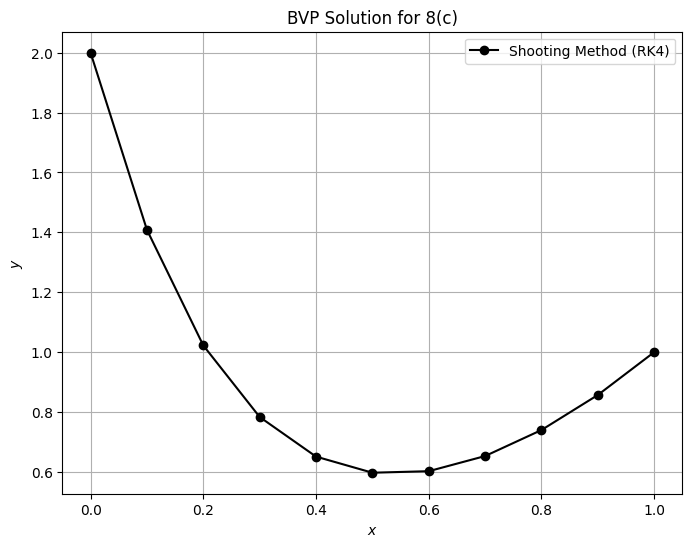

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters for 8b
a, b, n = 0, 1, 10
alpha, beta = -1, 0

def f_p_b(t, y):
    rhs = np.zeros((2, 1))
    rhs[0] = y[1]
    rhs[1] = -(t + 1)*y[1] + 2*y[0] + (1 - t**2)*np.exp(-t)
    return rhs

def f_h_b(t, y):
    rhs = np.zeros((2, 1))
    rhs[0] = y[1]
    rhs[1] = -(t + 1)*y[1] + 2*y[0]
    return rhs

# Solve yp
f = f_p_b
[t, wp_b] = tstep(a, b, np.array([[alpha], [0.0]]), n, 4)

# Solve yh
f = f_h_b
[t, wh_b] = tstep(a, b, np.array([[0.0], [1.0]]), n, 4)

# Combine
s_b = (beta - wp_b[0, -1]) / wh_b[0, -1]
w_b = wp_b + s_b * wh_b

# --- Table Generation ---
data_8c = {
    'i': np.arange(n + 1),
    'ti': t,
    'wp,i': wp[0, :],
    'wh,i': wh[0, :],
    'wi (Final)': w_final
}
df_8c = pd.DataFrame(data_8c)
pd.options.display.float_format = '{:.6f}'.format
print("Problem 8(b) Results:")
print(df_8c.to_string(index=False))

# --- Plotting ---
plt.figure(figsize=(8, 6))
plt.plot(t, w_final, '-o', color='black', label='Shooting Method (RK4)')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('BVP Solution for 8(c)')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import pandas as pd

# Get exact values at the time steps
y_ex = exact_6b(trk)
err_eu = np.abs(y_exact - weu[0, :])
err_tr = np.abs(y_exact - wtr[0, :])
err_rk = np.abs(y_exact - wrk[0, :])

# weu[0,:], wtr[0,:], and wrk[0,:] contain the y(t) approximations
data_b = {
    'i': np.arange(len(trk)),
    'ti': trk,
    'wi (RK4)': wrk[0, :],
    'y(ti) Exact': y_ex,
    'Error Euler': np.abs(y_ex - weu[0, :]),
    'Error Trap': np.abs(y_ex - wtr[0, :]),
    'Error RK4': np.abs(y_ex - wrk[0, :])
}

# 4. Create DataFrame and Format
df_6b = pd.DataFrame(data_b)

# Set format to scientific notation to see the precision of RK4
pd.options.display.float_format = '{:.6e}'.format

print("Problem 6(b) Summary Table (h = 0.1):")
print(df_6b.to_string(index=False))

# Optional: To save this to a CSV file for your assignment
# df_6b.to_csv('problem_6b_results.csv', index=False)

NameError: name 'exact_6b' is not defined

# Boundary Value Problems (BVP)
## The Linear Shooting Method

In [17]:
# Parameters
a = 0
b = np.pi/2
n = 4 # h = pi/8 implies (pi/2) / (pi/8) = 4 steps

# Boundary Conditions:
alpha = -0.3
beta = -0.1

# Initial Condition
yp0 = np.array([[],[]])


In [19]:
# Initial Condition
yh0 = np.array([[],[]])

# Define the Non-homogeneous system (yp)
def f_p(t, y):
    rhs = np.zeros((2, 1))
    rhs[0] = y[1] # y'
    rhs[1] = y[1] + 2*y[0] + np.cos(t) # y'' = y' + 2y + cos(x)
    return rhs

# Define the Homogeneous system (yh)
def f_h(t, y):
    rhs = np.zeros((2, 1))
    rhs[0] = y[1]
    rhs[1] = y[1] + 2*y[0] # Drop the cos(x) term
    return rhs
# --- Solve Non-homogeneous IVP ---
# We must temporarily redefine f to use tstep
f = f_p
yp0 = np.array([[alpha], [0.0]])
[t, wp] = tstep(a, b, yp0, n, 4)

# --- Solve Homogeneous IVP ---
f = f_h
yh0 = np.array([[0.0], [1.0]])
[t, wh] = tstep(a, b, yh0, n, 4)

# --- Combine Solutions ---
# s = (beta - wp_at_end) / wh_at_end
s = (beta - wp[0, -1]) / wh[0, -1]
w = wp + s * wh

In [20]:
≈

In [22]:
import pandas as pd

# 1. Define the exact solution for error comparison
# y(x) = -1/10 * (sin(x) + 3*cos(x))
y_ex = -0.1 * (np.sin(t) + 3 * np.cos(t))

# 2. Calculate the Shooting Parameter s
# beta is the boundary condition at t[last]
# wp[0,-1] is the non-homogeneous solution at t[last]
# wh[0,-1] is the homogeneous solution at t[last]
beta = -0.1
s = (beta - wp[0, -1]) / wh[0, -1]

# 3. Form the final combined solution w
w_final = wp[0, :] + s * wh[0, :]

# 4. Create the Data Dictionary
data_7 = {
    'i': np.arange(len(t)),
    'ti': t,
    'wp,i (Non-homog)': wp[0, :],
    'wh,i (Homog)': wh[0, :],
    'wi (Combined)': w_final,
    'y(ti) Exact': y_ex,
    'Error': np.abs(y_ex - w_final)
}

# 5. Create DataFrame and Format
df_7 = pd.DataFrame(data_7)
pd.options.display.float_format = '{:.6e}'.format

print(f"Linear Shooting Method Results (s = {s:.6f}):")
print(df_7.to_string(index=False))

Linear Shooting Method Results (s = -0.099792):
 i           ti  wp,i (Non-homog)  wh,i (Homog)  wi (Combined)   y(ti) Exact        Error
 0 0.000000e+00     -3.000000e-01  0.000000e+00  -3.000000e-01 -3.000000e-01 5.551115e-17
 1 3.926991e-01     -2.650158e-01  5.050394e-01  -3.154150e-01 -3.154322e-01 1.724168e-05
 2 7.853982e-01     -1.383948e-01  1.447306e+00  -2.828251e-01 -2.828427e-01 1.763864e-05
 3 1.178097e+00      1.321628e-01  3.400528e+00  -2.071844e-01 -2.071930e-01 8.612379e-06
 4 1.570796e+00      6.588350e-01  7.604130e+00  -1.000000e-01 -1.000000e-01 5.551115e-17


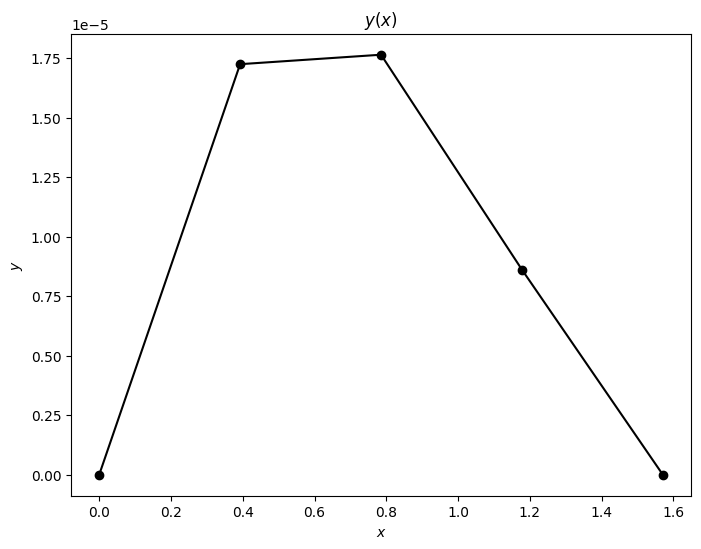

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(t,np.abs(y_exact - w[0,:]),'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$');